In [1]:
%%html
<script>


  // AUTORUN AND HIDE #@hidden CELLS ON NOTEBOOK-LOAD!
           require(
               ['base/js/namespace', 'jquery'],
               function(jupyter, $) {
                   $(jupyter.events).on("kernel_ready.Kernel", function () {
                       console.log("Auto-running and hiding all cells with # @ hidden comment...");
                       $('.cm-comment:contains(@hidden)').closest('div.input').hide();
                       var cells = $('.cm-comment:contains(@hidden)').closest('div.input').parents('.cell');
                       for (let i=0; i<cells.length; i++){
                           var id = Jupyter.notebook.get_cell_elements().index(cells[i]);
                           Jupyter.notebook.execute_cells([id]);
                       }
                       jupyter.actions.call('jupyter-notebook:save-notebook');
                   });
               }
           );
    $('.cm-comment:contains(@hidden)').closest('div.input').hide();
        
</script>

# Ligningsløsning

Vi vil lage et program som kan løse ligninger i 1 variabel for oss.
Vi ser eksempelvis på en ligning som oppstår når man vil finne ut hvilken vinkel man må skyte et prosjektil som har fast utgangshastighet med for å treffe en blink.

## Skrått kast

Vi har en kanon som står $7,00$ m over bakken. Kanonen skyter prosjektil med utgangshastighet $15,0$ m/s.
Vi ønsker å treffe en blink som ligger på bakken 28 meter unna. Hvilken utgangsvinkel må vi stille kanonen inn på?

### 2D-kinematikk
Dersom dere har gått forkurset, eller tatt F2 på videregående kjenner dere nok til 
hvordan man regner på bevegelse i 2 dimensjoner. Hvis ikke er ikke detaljene her så farlig - dere vil løse
liknende problemer et par uker inn i fysikken etter jul :)

For et såkalt skrått kast som problemet over beskriver, kan man se på x- og y- posisjonen til prosjektilet
uavhengig av hverandre:
$$
\begin{align}
x(t) &= v_0\cos{\theta}\cdot t \\
y(t) &= v_0\sin{\theta}\cdot t-\frac{1}{2}gt^2
\end{align}
$$
Her er $x(t)$ og $y(t)$ x- og y-posisjonen ved tiden $t$, $v_0$ er den faste utgangsfarten og $g$ er tyngdeakselerasjonen.

Vi vet at på et eller annet tidpunkt $t$, så må prosjektilet treffe blinken - den må innom $(x_b,y_b)= (-7,28)$.
Vi vet ikke når dette skjer (når prosjektilet lander), eller hvilken utgangvinkel vi trenger. Vi får da to ligninger med disse to ukjente:

$$
\begin{align}
x_b &= v_0\cos{\theta}\cdot t \\
y_b &= v_0\sin{\theta}\cdot t-\frac{1}{2}gt^2
\end{align}
$$
Her kan vi for eksempel løse den første ligningen for tiden $t$ og sette dette inn i ligning 2, og vi får etter
litt massasje:
$$
y_b = x_b\tan{\theta}-\frac{1}{2}g\left(\frac{x_b}{v_0\cos{\theta}}\right)^2
$$
Her er
$$
\begin{align}
y_b&= -7,00\ \text{m} \\
v_0 &= 15\ \text{m/s} \\
x_b &= 28,0\ \text{m}
\end{align}
$$
Siste steg er å løse følgende liking for $\theta$
$$
-7 = 28\tan{\theta}-4.905\left(\frac{28}{15\cos{\theta}}\right)^2
$$

Denne likningen er ikke så lett å løse, selv om vi kan leke litt med figuren under og se at den *har* 2 løsninger. Det er ikke så lett å disse løsningene analytisk, men ligningen er en god kandidat til å løses *numerisk*. Andre likninger kan det være *umulig* å finne en analytisk løsning til, feks $x+\sin{x} = 1$



In [2]:
%%html
<!-- #@hidden -->
<link href="https://cdn.jsdelivr.net/npm/jsxgraph@1.5.0/distrib/jsxgraph.css" rel="
stylesheet" type="text/css" />

<script>
require.config({ 
     paths: { 
     JXG: 'https://cdn.jsdelivr.net/npm/jsxgraph@1.5.0/distrib/jsxgraphcore' //no .js extension
}});
</script>


<h1>Kanon!</h1>


<input type="button" value="Skyt" id="button_shoot">
<div id="jxgbox" class="jxgbox" style="width:600px; height:400px;"></div>
<script>
    require(['JXG'], function(JXG) {
      var g = 9.81
      var h = 8
      var v0_val = 15
      var board = JXG.JSXGraph.initBoard('jxgbox', {boundingbox: [-2, 20, 32, -10], axis: true});
      var circ = board.create('circle', [[0,h],v0_val/3]).hide()
      var v0p = board.create('glider', [circ], {name: "", size: 0.1});
      var v0 = board.create('arrow', [[0,h],[()=>v0p.X(), ()=>v0p.Y()]]);
      var startP = board.create('point', [0,h]).hide();
      var hiddenP = board.create('point', [4,h]).hide();
      //var slid_t = board.create('slider', [[0,20], [10,20], [0,0,5]]);
      var ti = board.create('point', [0,0]).hide();

      var ang_line = board.create('segment', [[0,h], [4,h]], {dash: 1});
      var angle = board.create('angle', [hiddenP, startP,v0p ], {name: function() 
         {
            return JXG.Math.Geometry.trueAngle(hiddenP, startP,v0p).toFixed(1) + '°';
         }
      });


      var x_t = function(t) {
         return v0_val*Math.cos(2*Math.PI/360*JXG.Math.Geometry.trueAngle(hiddenP, startP,v0p))*t;
      };

      var y_t = function(t) {
         return h+v0_val*Math.sin(2*Math.PI/360*JXG.Math.Geometry.trueAngle(hiddenP, startP,v0p))*t-0.5*g*t*t;
      }

      var pos = board.create('curve', [x_t, y_t, 0, ()=>ti.X()],
         {
            dash: 1
         });
      
      var vel = board.create('arrow', [[()=>x_t(ti.X()), ()=>y_t(ti.X())], 
         [()=>x_t(ti.X())+v0_val/3*Math.cos(2*Math.PI/360*JXG.Math.Geometry.trueAngle(hiddenP, startP,v0p)), 
            ()=>y_t(ti.X())+v0_val/3*Math.sin(2*Math.PI/360*JXG.Math.Geometry.trueAngle(hiddenP, startP,v0p))-g*ti.X()/3]
         ]);

      var button = document.getElementById("button_shoot");
      button.addEventListener("click",function (){
         ti.setPositionDirectly(JXG.COORDS_BY_USER,[0,0]);
         ti.moveTo([5,0], 5000);
      });
    });
</script>



## Grafisk løsning

Når man støter på en likning man ikke får helt til å løse, kan man prøve å løse den
grafisk. En likning består av 2 matematiske uttrykk, et på venstre- og et på høyre side av et $=$ (likhetstegn). 
Likninger har ofte en ukjent $x$ som vi sliter og styrer for å finne, og vi kan betrakte uttrykkene på venstre og høyre side av ligningen som to funskjoner i $x$:
$$
V(x) = H(x)
$$
Vi kan for eksempel ha at $V(x) = x$ og $H(x) = \cos{x}$, da blir ligningen vi forsøker å løse $x = \cos{x}$.
Vi kan da plotte $V(x)$ og $H(x)$ grafisk, og siden det å løse ligningen er å spørre *for hvilke verdier av $x$ er høyre og venstre side av likhetstegnet likt* vil løsningene være å finne der hvor $V(x)$ og $H(x)$ krysser hverandre, *da har de samme verdi*

### Oppgave 1
Lag to funksjoner `def V(thet):` og `def H(thet):` som representerer kanonkuleligningen vi vil prøve å løse. Argumentet `thet` er vinkelen vi prøver å finne. 
Plot deretter de to funksjonene i samme figur og se om du kan lese av eventuelle løsninger. Sjekk løsningene i prosjektilskytefigurtingen over

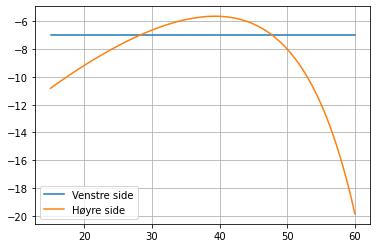

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#BEGIN SOLUTION
y_bakke = -7
g = 9.81
x_lengde = 28
v0 = 15
#END SOLUTION

def V(thet):
    #BEGIN SOLUTION
    return y_bakke;
    #END SOLUTION
    
def H(thet):
    #BEGIN SOLUTION
    theta = np.deg2rad(thet)
    return x_lengde*np.tan(theta)-0.5*g*(x_lengde/v0/np.cos(theta))**2

    
n = 100
x = np.linspace(15,60,n)
vs = [V(thet) for thet in x]
hs = [H(thet) for thet in x]
plt.plot(x,vs,label="Venstre side" )
plt.plot(x,hs, label="Høyre side")
plt.grid()
plt.legend()
plt.show()
#END SOLUTION

In [4]:
#BEGIN HIDDEN TESTS
assert 1==1
#END HIDDEN TESTS

## Ligningsløsning er som å finne røtter til funksjoner

I numerikk løser vi ofte ligninger ved å omforme problemet til å finne *roten* av en funksjon.
Si vi har en ligning vi ikke klarer løse analytisk: $\cos{x] = x$.
For alle ligninger vi er kjente med, kan vi flytte alle leddene over på en side av likhetstegnet slik at vi får feks:
$$
\cos{x} -x = 0
$$
Å løse ligningen betyr av vi vil finne en $x$ slik at $\cos{x} -x = 0$, problemet blir altså det samme som å
finne roten til funksjonen:
$$
f(x) = \cos{x}-x
$$
Å finne vinkelen vi må stille inn kanonen vår på, blir altså det samme som å finne en rot til funksjonen
$$
F(x) =  x_b\tan{\theta}-\frac{1}{2}g\left(\frac{x_b}{v_0\cos{\theta}}\right)^2-y_b
$$
### Oppgave 2
Lag denne funksjonen i python som `def F(thet):`, og plot den i en figur og sjekk at du får samme løsninger som i oppgave 1.

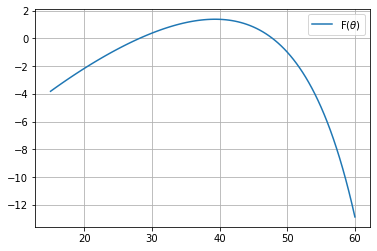

In [5]:
def F(thet):
    ### BEGIN SOLUTION
        theta = np.deg2rad(thet)
        return x_lengde*np.tan(theta)-0.5*g*(x_lengde/v0/np.cos(theta))**2-y_bakke

    
n = 100
x = np.linspace(15,60,n)
funk = [F(thet) for thet in x]
plt.plot(x,funk,label=r"F($\theta$)" )

plt.grid()
plt.legend()
plt.show()
#END SOLUTION

## Ligningsløser

Da kan vi prøve å lage en ligningsløser. Vi skal skrive en ligningsløser som tar, minst en funksjon `f` og en toleranse for nøyaktigheten til løsningen, og returnerer en rot til denne funksjonen innen toleransen. Men hvordan?

### Oppgave 3
Lag en funksjon `def stupid_solve(f,tol,intervall):` som trekker tilfeldige verdier $x_{tipp}$ helt til den har funnet en verdi som er tilstrekkelig nærme roten $\implies f(x_{tipp}) \approx 0$.

Funksjonen skal ta en funksjon `f` som vi skal finne en rot til, en toleranseverdi `tol` og et tuple `intervall` ,$(a,b)$, som angir mellom hvilke verdier vi skal «tippe» på løsninger. 

In [6]:
from random import random

def stupid_solve(f,tol,intervall):
    a,b = intervall
    tipp = a+random()*(b-a)
    verdi = f(tipp)
    while np.abs(verdi)>tol:
        tipp = a+random()*(b-a)
        verdi = f(tipp)
    return tipp

toleranse = 1e-4
rot = stupid_solve(F,toleranse, (15,60))
print(f"Vi har funnet en løsning! vinkel: {rot}")

Vi har funnet en løsning! vinkel: 47.80240234417632


Å tippe vilt og uhemmet på løsninger er kanskje ikke den smarteste fremgangsmåten.
Dersom vi bare skal lete etter en løsning uten noen større strategi enn å sjekke forskjellige potensielle verdier, burde vi i det minste gå systematisk frem.

### Oppgave 4

Lag en funksjon `def less_stupid_solve(f,tol,intervall):` hvor funksjonsargumentene er de samme som for funksjonen over. Denne gangen går vi heller systematisk frem: Funksjonen skal lage en liste verdier mellom $(a,b)$ gitt av tuplen `intervall`. Avstanden mellom verdiene i listen er gitt av `tol` slik av vi vet at vi ikke bommer på korrekt løsning med mer enn denne toleranseverdien. Funksjonen finner en rot ved å velge ut og returnere verdien $x$ fra listen av verdier som gir $f(x)$ nærmest $0$

In [7]:
def less_stupid_solve(f, tol, intervall):
    a,b = intervall
    x_verdier = np.arange(a,b,tol)
    funk_verdier = [(xi,f(xi)) for xi in x_verdier]
    return min(funk_verdier, key=lambda tup: abs(tup[1]))[0]

rot = less_stupid_solve(F, toleranse, (15,60))
print(f"Vi har funnet en løsning mer systematisk! vinkel: {rot}")

Vi har funnet en løsning mer systematisk! vinkel: 47.80259999992355


Denne fremgangsmåten burder være mye raskere, lurere og bedre. Sjekk dette ut selv, løs kanonkuleproblemet for forskjellige toleranser. Det kan se ut som det er raskere å tippe masse vinkler og sjekke, enn å systematisk til verks. *Det kan umulig stemme?!*

Klarer du å finne ut hvorfor? (*Hint: hvordan bruker vi toleransen i de to tilfellene*)

Uansett så er å lete blindt, enten systematisk eller målløst, ikke en strategi som vil funke særlig bra.
Her trenger vi en skikkelig numerisk metode:

# Halveringsmetoden

Halveringsmetoden eller biseksjonsmetoden forsøker å finne en rot ved å .... **Beskrivelse her**


### Oppgave 5
Implementer halveringsmetoden - bruk gjerne figuren under til hjelp

In [8]:
%%html
<!-- #@hidden -->
<link href="https://cdn.jsdelivr.net/npm/jsxgraph@1.5.0/distrib/jsxgraph.css" rel="
stylesheet" type="text/css" />

<script>
require.config({ 
     paths: { 
     JXG: 'https://cdn.jsdelivr.net/npm/jsxgraph@1.5.0/distrib/jsxgraphcore' //no .js extension
}});
</script>


<h1>Halveringsmetoden</h1>

<input type="button" value="Neste steg" id="neste_butt">
<input type="button" value="Restart" id="restart_butt">
<div id="jxgbox1" class="jxgbox" style="width:600px; height:400px;"></div>
Rot: <input type="textbox" id="outpu">
<script>
    require(['JXG'], function(JXG) {
     JXG.Options.text.useMathJax = true;
      var y = -7;
      var x = 28;
      var g = 9.81;
      var v0 = 15;

      
      
      function F(tet)
      {
         tet2 = 2*Math.PI*tet/360;
         return x*Math.tan(tet2)-0.5*g*Math.pow(x/(v0*Math.cos(tet2)),2)-y;
      }
      
      var board = JXG.JSXGraph.initBoard("jxgbox1", {boundingbox: [-5,3, 45,-7], axis:true,
         defaultAxes: {
            x: {name: "X", withLabel: true, label: {position: "rt", offset: [-10,10]}},
            y: {name: "Y", withLabel: true, label: {position: "rt", offset: [10,-20]}}
         }
      });

      
      
      var graph = board.create('functiongraph', [F, -10,60]);

      var p1 = board.create('point', [20,0], {name: "\\(a\\)", fixed:true});
      var fp1 = board.create('point', [()=>p1.X(),()=>F(p1.X())], {name: "\\(f(a)\\)", fixed:true}).hide();
      var p2 = board.create('point', [40,0], {name: "\\(b\\)", fixed:true});
      var fp2 = board.create('point', [()=>p2.X(),()=>F(p2.X())], {name: "\\(f(b)\\)", fixed:true}).hide();
      var line1 = board.create('line', [()=>p1,()=>fp1], {dash:3, straightLast:false, straightFirst:false}).hide();
      var line2 = board.create('line', [()=>p2,()=>fp2], {dash:3, straightLast:false, straightFirst:false}).hide();


      
      var dist = p1.Dist(p2);
      console.log("dist", dist);
      console.log("scrCoords", p1.coords.scrCoords);
      console.log("scrCoords 2", p2.coords.scrCoords);
      dist = p1.coords.distance(JXG.COORDS_BY_SCREEN, p2.coords);
      console.log("dist 2", dist);
      


      function get_midX()
      {
         return (p2.X()+p1.X())/2;
      }
      
      var line_mid = board.create('line', [[()=>get_midX(),0], [()=>get_midX(), ()=>F(get_midX())]], {dash:3}).hide();
      var p_mid = board.create('point', [()=>get_midX(),()=>F(get_midX())], {name: "\\(f(x_m)\\)"}).hide();
      

      var count = 0;

      var next_button  = document.getElementById("neste_butt");
      var reset_button = document.getElementById("restart_butt");
      var output = document.getElementById("outpu");


      function checkAndRescale()
      {
         dist = p1.coords.distance(JXG.COORDS_BY_SCREEN, p2.coords);
         console.log("Distance between a b on screen", dist);
         if (dist <= 60)
         {
            var dist_usr = p1.Dist(p2)
            var xx1 = p1.X()-dist_usr;
            var xx2 = p2.X()+dist_usr;
            board.setBoundingBox([xx1, Math.max(F(xx1), F(xx2)), xx2, Math.min(F(xx1), F(xx2))], false);
            board.update();
         }
      }


      next_button.addEventListener("click",(function (){
         var step = count%3
         count += 1;

         if (step == 0)
         {
            fp1.show();
            fp2.show();
            line1.show();
            line2.show();
         }
         else if (step==1)
         {
            line_mid.show();
            p_mid.show();
         }
         else
         {
            p_mid.hide();
            line_mid_temp = board.create('line', [[get_midX(),0], [get_midX(), F(get_midX())]], {dash:3});
            line_mid.hide();
            if (Math.sign(fp1.Y()) == Math.sign(p_mid.Y()))
            {
               fp1.hide();
               line1.hide();
               p1.moveTo([get_midX(),0],1000, {callback: (function(){
                  board.removeObject(line_mid_temp);
                  output.value = get_midX();
                  checkAndRescale();
                  })
               });
               fp2.hide();
               line2.hide();
            }
            else
            {
               fp2.hide();
               line2.hide();
               p2.moveTo([get_midX(),0],1000, {callback: (function(){
                  board.removeObject(line_mid_temp);
                  output.value = get_midX();
                  checkAndRescale();
                  })
               });
               fp1.hide();
               line1.hide();
            }
         }
         })
      );

      reset_button.addEventListener("click", (function(){
         count = 0;
         p1.setPositionDirectly(JXG.COORDS_BY_USER,[20,0]);
         p2.setPositionDirectly(JXG.COORDS_BY_USER,[40,0]);
         fp1.hide();
         fp2.hide();
         line1.hide();
         line2.hide();
         line_mid.hide();
         p_mid.hide();
         board.setBoundingBox([-5,3, 45,-7], false);
         board.update();
      }));
    });
</script>



In [18]:
def halvering_solve(f,tol,a,b):
    fa = f(a)
    fb = f(b)
    midt = (a+b)/2
    fmidt = f(midt)
    ii = 0
    while b-a > tol:
        if fa*fmidt > 0:
            b = midt
            fb = f(b)
        else:
            a = midt
            fa = f(a)
        midt = (a+b)/2
        fmidt = f(midt)
    return midt

a = 20
b = 40
rot = halvering_solve(F, 1e-2,a,b)
print(f"Vi har funnet en løsning med halveringsmetoden! vinkel: {rot}")
print(f"a,b", a,b)
                

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [10]:
%%html
<!-- #@hidden -->
<h1>Halveringsmetoden</h1>
Slik har du implementert halveringsmetoden. <br>
Dersom du forandrer på funksjonen din trykk
<input type="button" value="Hent din metode" id="reload_butt">
<script>
   var reload_button  = document.getElementById("reload_butt");
 
          reload_button.addEventListener("click", (function(){
          console.log("Execute?!")
          var this_cell = $('.cm-comment:contains(@feedback_halvering)').closest('div.input').parents('.cell');
          var cell_idx = Jupyter.notebook.get_cell_elements().index(this_cell);
          Jupyter.notebook.execute_cells([cell_idx])

      }));
</script>

In [15]:
from IPython.core.display import HTML
import json
#@feedback_halvering
#@hidden
iters = dict()
a = 20
b = 40
midt = halvering_solve(F,b-a+1e-4,a,b)
iters.update({"0":{"a": a, "b": b, "m": midt}})
for i in range(1,10):
    select = halvering_solve(F,b-a-1e-4,a,b)
    if midt>select:
        b=midt
    else:
        a=midt
    midt = select
    iters.update({f"{i}":{"a": a, "b": b, "m": midt}})
stud_vals = json.dumps(iters)
print(stud_vals)
HTML("""

<link href="https://cdn.jsdelivr.net/npm/jsxgraph@1.5.0/distrib/jsxgraph.css" rel="
stylesheet" type="text/css" />

<script>
require.config({ 
     paths: { 
     JXG: 'https://cdn.jsdelivr.net/npm/jsxgraph@1.5.0/distrib/jsxgraphcore' //no .js extension
}});
</script>

<input type="button" value="Neste steg" id="neste_butt2">
<input type="button" value="Restart" id="restart_butt2">
<div id="jxgbox2" class="jxgbox" style="width:600px; height:400px;"></div>
Rot: <input type="textbox" id="outpu">
<script>
    require(['JXG'], function(JXG) {
     JXG.Options.text.useMathJax = true;
      var y = -7;
      var x = 28;
      var g = 9.81;
      var v0 = 15;
      console.log("Execute!");"""+f"\nvar stud_ans = {stud_vals};"+"""
      console.log(stud_ans);
      function F(tet)
      {
         tet2 = 2*Math.PI*tet/360;
         return x*Math.tan(tet2)-0.5*g*Math.pow(x/(v0*Math.cos(tet2)),2)-y;
      }
      
      var board = JXG.JSXGraph.initBoard("jxgbox2", {boundingbox: [-5,3, 45,-7], axis:true,
         defaultAxes: {
            x: {name: "X", withLabel: true, label: {position: "rt", offset: [-10,10]}},
            y: {name: "Y", withLabel: true, label: {position: "rt", offset: [10,-20]}}
         }
      });

      
      
      var graph = board.create('functiongraph', [F, -10,60]);

      var p1 = board.create('point', [20,0], {name: "\\\(a\\\)", fixed:true});
      var fp1 = board.create('point', [()=>p1.X(),()=>F(p1.X())], {name: "\\\(f(a)\\\)", fixed:true}).hide();
      var p2 = board.create('point', [40,0], {name: "\\\(b\\\)", fixed:true});
      var fp2 = board.create('point', [()=>p2.X(),()=>F(p2.X())], {name: "\\\(f(b)\\\)", fixed:true}).hide();
      var line1 = board.create('line', [()=>p1,()=>fp1], {dash:3, straightLast:false, straightFirst:false}).hide();
      var line2 = board.create('line', [()=>p2,()=>fp2], {dash:3, straightLast:false, straightFirst:false}).hide();


      
      var dist = p1.Dist(p2);
      console.log("dist", dist);
      console.log("scrCoords", p1.coords.scrCoords);
      console.log("scrCoords 2", p2.coords.scrCoords);
      dist = p1.coords.distance(JXG.COORDS_BY_SCREEN, p2.coords);
      console.log("dist 2", dist);
      var count = 0;    
      var iter = 0;

      function get_midX()
      {
         //return (p2.X()+p1.X())/2;
         return stud_ans[iter.toString()]["m"];
      }
      
      var line_mid = board.create('line', [[()=>get_midX(),0], [()=>get_midX(), ()=>F(get_midX())]], {dash:3}).hide();
      var p_mid = board.create('point', [()=>get_midX(),()=>F(get_midX())], {name: "\\\(f(x_m)\\\)"}).hide();
      



      var next_button  = document.getElementById("neste_butt2");

      var reset_button = document.getElementById("restart_butt2");
      var output = document.getElementById("outpu");


      function checkAndRescale()
      {
         dist = p1.coords.distance(JXG.COORDS_BY_SCREEN, p2.coords);
         console.log("Distance between a b on screen", dist);
         if (dist <= 60)
         {
            var dist_usr = p1.Dist(p2)
            var xx1 = p1.X()-dist_usr;
            var xx2 = p2.X()+dist_usr;
            board.setBoundingBox([xx1, Math.max(F(xx1), F(xx2),0.5), xx2, Math.min(F(xx1), F(xx2),-0.5)], false);
            board.update();
         }
      }


      next_button.addEventListener("click",(function (){
         if (iter >=9)
         {
             return;
         }
         var step = count%3
         count += 1;

         if (step == 0)
         {
            fp1.show();
            fp2.show();
            line1.show();
            line2.show();
         }
         else if (step==1)
         {
            line_mid.show();
            p_mid.show();
         }
         else
         {
            p_mid.hide();

            line_mid_temp = board.create('line', [[get_midX(),0], [get_midX(), F(get_midX())]], {dash:3});
            line_mid.hide();

            //if (Math.sign(fp1.Y()) == Math.sign(p_mid.Y()))
            if (stud_ans[iter.toString()]["m"] == stud_ans[(iter+1).toString()]["a"] )
            {
               fp1.hide();
               line1.hide();
               p1.moveTo([get_midX(),0],1000, {callback: (function(){
                  board.removeObject(line_mid_temp);
                  output.value = get_midX();
                  checkAndRescale();
                  })
               });
               fp2.hide();
               line2.hide();
            }
            else
            {
               fp2.hide();
               line2.hide();
               p2.moveTo([get_midX(),0],1000, {callback: (function(){
                  board.removeObject(line_mid_temp);
                  output.value = get_midX();
                  checkAndRescale();
                  })
               });
               fp1.hide();
               line1.hide();
            }
            iter += 1;

         }
         })
      );

      reset_button.addEventListener("click", (function(){
         count = 0;
         p1.setPositionDirectly(JXG.COORDS_BY_USER,[20,0]);
         p2.setPositionDirectly(JXG.COORDS_BY_USER,[40,0]);
         fp1.hide();
         fp2.hide();
         line1.hide();
         line2.hide();
         line_mid.hide();
         p_mid.hide();
         board.setBoundingBox([-5,3, 45,-7], false);
         board.update();
      }));

    });
</script>
""")

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

# BLA BLA BLA Newtons metode


In [12]:
#Vise litt sympy? :)

import sympy as smp

t_smp = smp.Symbol("t")
theta_smp = smp.Symbol("theta")
f_smp = smp.Symbol("f")
f_smp = x_lengde*smp.tan(theta_smp)-0.5*g*(x_lengde/v0/smp.cos(theta_smp))**2-y_bakke
df_smp = smp.diff(f_smp,theta_smp)
df = smp.lambdify(theta_smp, df_smp)
df_smp

-34.1824*sin(theta)/cos(theta)**3 + 28*tan(theta)**2 + 28

# Eulers - rakettkanonkule

Vi kopler en rakett på kanonkulen vår for ekstra fart og spenning.
Vi har vært dyktige ingeniører slik at kraften fra raketten virker gjennom massesenteret på kanonkulen $\implies$ den bidrar ikke til at kanonkulen begynner å spinne.
Dessverre var ingeniøren som lagde kanonen like flink: Kanonkulen får en rotasjon når den blir skutt ut på 2 omdreininger i sekundet (mot klokken i xy-planet)

Karakteristikk masse til rakett, og farten til raketteksosen er gitt ved grafene.
Drivkraft til rakett `def Thrust(t)` også gitt som funksjon av tiden.
Hvordan ser dette ut?


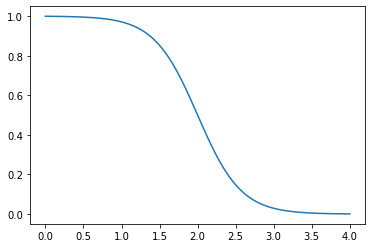

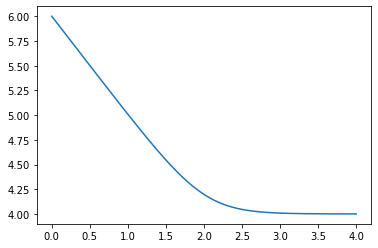

In [13]:
t_smp, v0_smp, v_smp, a_smp, m_smp, p_smp, T_smp, v_topp = smp.symbols("t v0 v a m p T vm")
v_smp = 1/(1+smp.exp((t_smp-2)*3.5))
v_fun = smp.lambdify(t_smp,v_smp)
t = np.linspace(0,4,1000)
v_plot = v_fun(t)
plt.plot(t,v_plot)
plt.show()
m_smp = 4-smp.integrate(v_smp,t_smp)
m_fun = smp.lambdify(t_smp, m_smp)
m_plot = m_fun(t)
plt.plot(t,m_plot)
plt.show()
p_smp = m_smp*v_smp
T_smp = smp.diff(p_smp,t_smp)
T_smp
T_fun = smp.lambdify(t_smp, T_smp, modules="numpy")

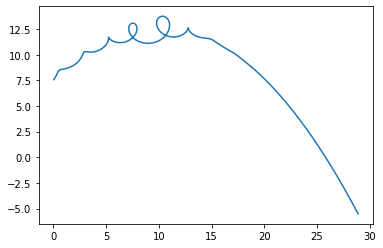

In [14]:
omega = 2*np.pi*2
def Thrust(t): #Thrust fra rakettmotor (#Gitt)
    return 200*np.array([
        np.cos(omega*t)*T_fun(t),
        np.sin(omega*t)*T_fun(t)
    ])
def F_sum(t): #Summen av kreftene
    return Thrust(t)+np.array([0, -g]) #Oppgave -> finn summen av kreftene (Tyngdekraft i tillegg)

def m(t):#Masse av kanonkulerakett som funk av tid (#gitt)
    return m_fun(t)

def a(t): #Akselerasjon som funksjon av tiden (#lages?)
    return F_sum(t)/m(t)

def euler(f, h, y0, t_slutt): #Eulers metode -- null forandringer :)
    t_i = 0.0
    y = []
    while t_i < t_slutt:
        y_i = y0 +h*f(t_i,y0)
        y0 = y_i
        y.append(y_i)
        t_i += h
    return y

v0 = np.array([5,7])

#Dette er litt tricky å sette seg inn i kanskje
def f_funk(t,y): # Derivert av y-system ([pos, fart], derivert -> [fart, akselerasjon])
    aks = a(t)
    return np.array([
        y[1],
        a(t)
    ])

y0 = np.array([[0,7.5],[5,7]]) # STARTVEKTOR [pos, fart]

ysl = euler(f_funk, 0.01, y0, 6) # -> Gir tilbake liste av 2d vektorer for posisjon/tid

x = [ys[0,0] for ys in ysl] # Hent ut x-posisjon
y = [ys[0,1] for ys in ysl] # Hent ut y-posisjon

plt.plot(x, y)
#plt.ylim(0,5)
#plt.xlim(0,20)
yi = y0+0.2*np.array([y0[1], [0,0]])